<a href="https://www.kaggle.com/code/esracum/fish-eye-dewarping?scriptVersionId=303580342" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

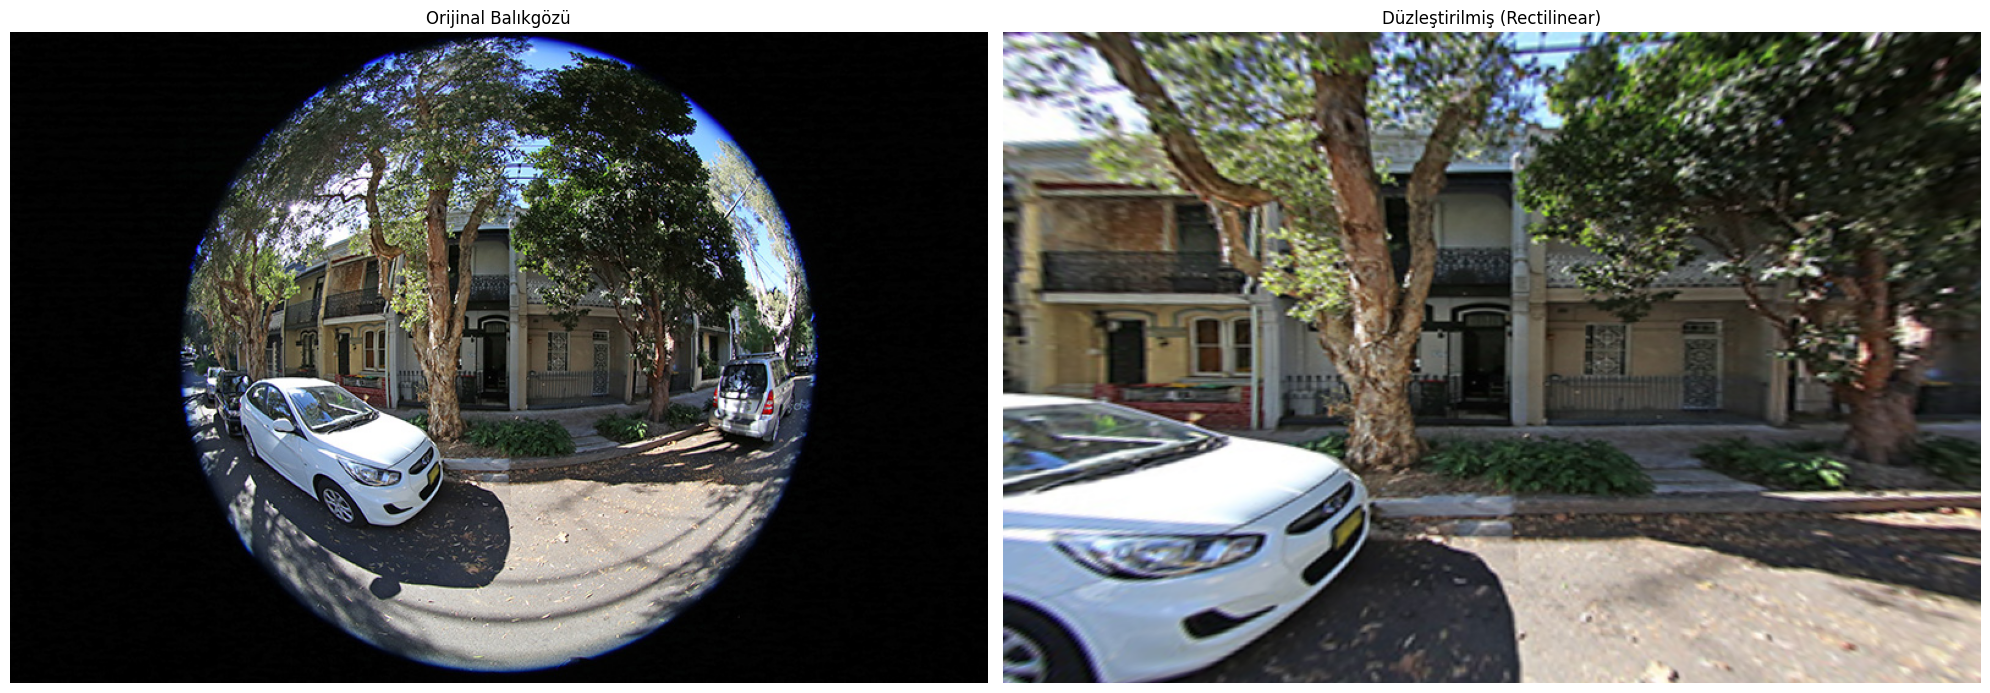

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dewarp_rectilinear(img, zoom=0.7):
    h, w = img.shape[:2]
    cx, cy = w / 2, h / 2
    
    # Çıktı görüntüsü için koordinat sistemi oluştur
    y, x = np.indices((h, w), dtype=np.float32)
    
    # Koordinatları merkeze göre normalize et
    x_norm = (x - cx) / (cx * zoom)
    y_norm = (y - cy) / (cy * zoom)
    
    # Polar koordinatlara dönüştür
    r = np.sqrt(x_norm**2 + y_norm**2)
    theta = np.arctan(r)
    
    # Balıkgözü lensin dairesel yarıçapına uyarla
    r_fisheye = theta / (np.pi / 2) * (min(h, w) / 2)
    
    # Yeni koordinatları hesapla
    mask = r > 0
    map_x = np.full_like(x, cx)
    map_y = np.full_like(y, cy)
    
    map_x[mask] = (r_fisheye[mask] * x_norm[mask] / r[mask]) + cx
    map_y[mask] = (r_fisheye[mask] * y_norm[mask] / r[mask]) + cy
    
    # Görüntüyü yeniden eşle
    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

# Kaggle dosya yolu
input_path = '/kaggle/input/datasets/esracum/datatest/fisheye.jpg'
img = cv2.imread(input_path)

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Düzleştirme işlemi
    result = dewarp_rectilinear(img_rgb, zoom=0.8)

    # Yan yana görselleştirme
    plt.figure(figsize=(20, 10))

    # 1. Resim: Orijinal
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Orijinal Balıkgözü")
    plt.axis('off')

    # 2. Resim: Düzleştirilmiş
    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Düzleştirilmiş (Rectilinear)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Hata: Dosya {input_path} yolunda bulunamadı.")

In [2]:
# Görüntü Matplotlib için RGB formatındaydı, 
# OpenCV ile kaydetmek için tekrar BGR formatına çevirmeliyiz.
output_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)

# Belirlediğiniz isimle çalışma dizinine kaydeder
output_path = '/kaggle/working/duzlestirilmis_resim.jpg'
cv2.imwrite(output_path, output_bgr)

print(f"Görüntü başarıyla kaydedildi: {output_path}")

Görüntü başarıyla kaydedildi: /kaggle/working/duzlestirilmis_resim.jpg


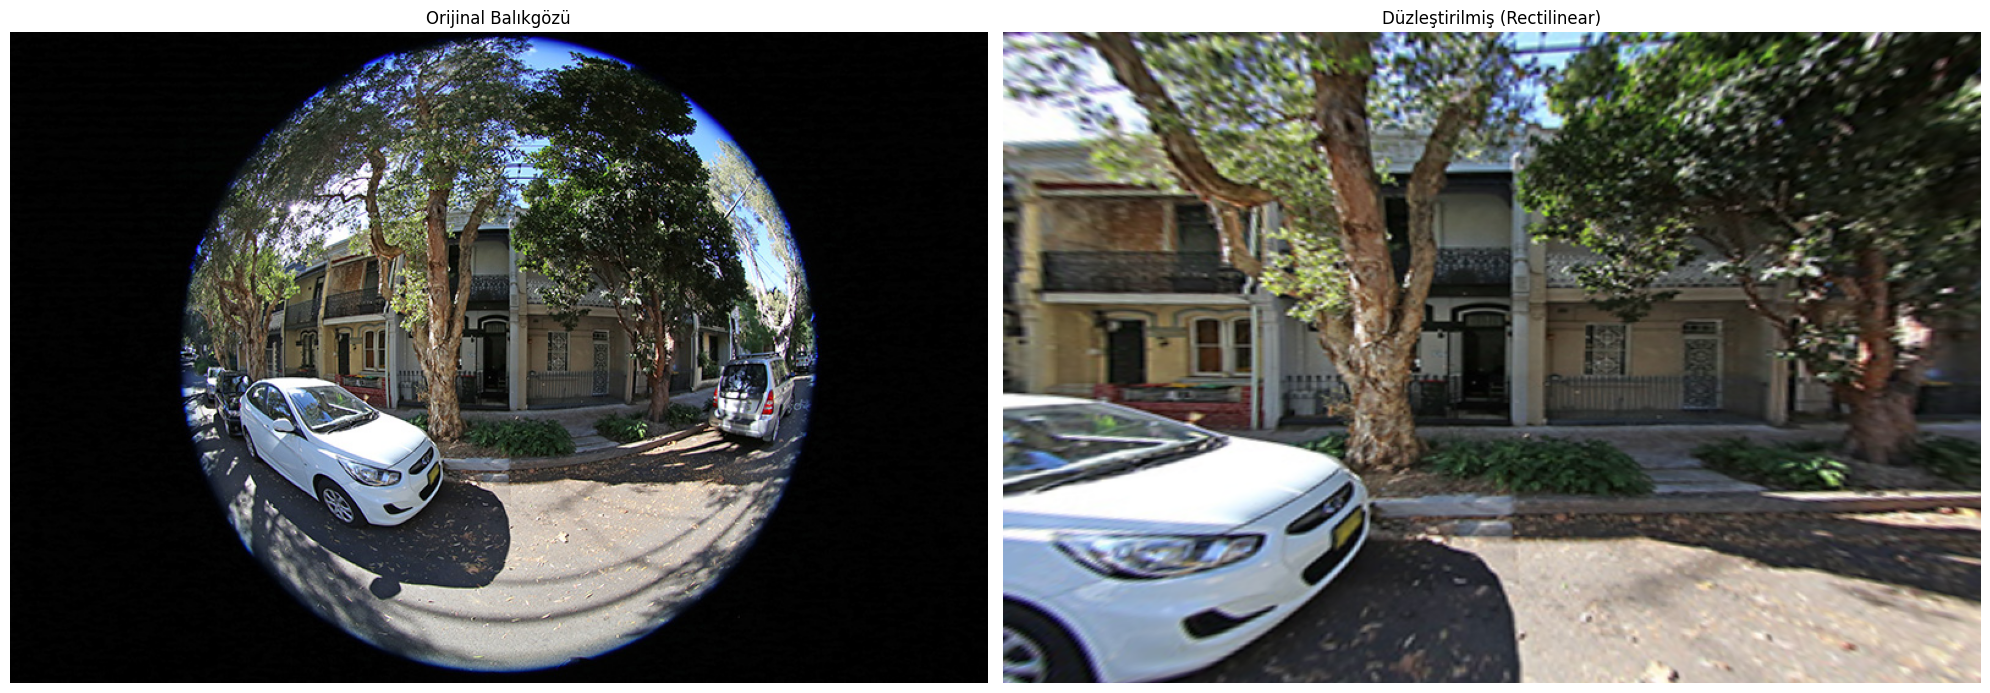

Dosya kaydedildi: /kaggle/working/karsilastirma.png


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dewarp_rectilinear(img, zoom=0.7):
    h, w = img.shape[:2]
    cx, cy = w / 2, h / 2
    y, x = np.indices((h, w), dtype=np.float32)
    x_norm = (x - cx) / (cx * zoom)
    y_norm = (y - cy) / (cy * zoom)
    r = np.sqrt(x_norm**2 + y_norm**2)
    theta = np.arctan(r)
    r_fisheye = theta / (np.pi / 2) * (min(h, w) / 2)
    mask = r > 0
    map_x = np.full_like(x, cx)
    map_y = np.full_like(y, cy)
    map_x[mask] = (r_fisheye[mask] * x_norm[mask] / r[mask]) + cx
    map_y[mask] = (r_fisheye[mask] * y_norm[mask] / r[mask]) + cy
    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

# Dosya yolu (Kendi yolunuza göre güncelleyin)
input_path = '/kaggle/input/datasets/esracum/datatest/fisheye.jpg'
img = cv2.imread(input_path)

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = dewarp_rectilinear(img_rgb, zoom=0.8)

    # Görselleştirme ve Kayıt Hazırlığı
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Orijinal Balıkgözü")
    axes[0].axis('off')

    axes[1].imshow(result)
    axes[1].set_title("Düzleştirilmiş (Rectilinear)")
    axes[1].axis('off')

    plt.tight_layout()
    
    # Resmi Kaggle çalışma dizinine kaydet
    save_path = '/kaggle/working/karsilastirma.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Dosya kaydedildi: {save_path}")
else:
    print("Görüntü yüklenemedi.")